# Building Model
For this assignment, I will utilise Term Frequency-Inverse Document Frequency (TF-IDF), which will vectorise text by measuring a word's importance to a document relative to a corpus and Logistic Regression as a Binary Classifier between Stressed (Label=1) and Not Stressed (Label=0).

I will build a Baseline Model, inputting the results of TF-IDF into the Logistic Regression Model, with and without Preprocessing of Text. I will improve the Model using TF-IDF and pre-computed LIWC (Linguistic Inquiry and Word Count counting words belonging to predefined psychological categories) Lexicon Scores, DAL Lexicon Scores (measuring Emotional Dimensions, Pleasantness, Activation and Imagery) and Sentiment (measirong Positive/Negative Polarity) features, inputted into the Logistic Regression Model. The reason for including these is to provide a nuanced "flavour" of text beyond word vectors in the predictive model.

## Import Modules

In [375]:
import pandas as pd
import numpy as np
import spacy
from nltk.corpus import stopwords
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import math

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif

import torch
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset

nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")

from scipy.sparse import csr_matrix
from scipy.sparse import hstack


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Haidah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load Data

In [352]:
df_train = pd.read_csv("dreaddit-train.csv")
df_test = pd.read_csv("dreaddit-test.csv")

#print(df_train.head())
#print(df_test.head())

print(df_train.columns)
print(df_test.columns)

print(df_train['label'].value_counts())
print(df_test['label'].value_counts())

Index(['subreddit', 'post_id', 'sentence_range', 'text', 'id', 'label',
       'confidence', 'social_timestamp', 'social_karma', 'syntax_ari',
       ...
       'lex_dal_min_pleasantness', 'lex_dal_min_activation',
       'lex_dal_min_imagery', 'lex_dal_avg_activation', 'lex_dal_avg_imagery',
       'lex_dal_avg_pleasantness', 'social_upvote_ratio',
       'social_num_comments', 'syntax_fk_grade', 'sentiment'],
      dtype='object', length=116)
Index(['id', 'subreddit', 'post_id', 'sentence_range', 'text', 'label',
       'confidence', 'social_timestamp', 'social_karma', 'syntax_ari',
       ...
       'lex_dal_min_pleasantness', 'lex_dal_min_activation',
       'lex_dal_min_imagery', 'lex_dal_avg_activation', 'lex_dal_avg_imagery',
       'lex_dal_avg_pleasantness', 'social_upvote_ratio',
       'social_num_comments', 'syntax_fk_grade', 'sentiment'],
      dtype='object', length=116)
label
1    1488
0    1350
Name: count, dtype: int64
label
1    369
0    346
Name: count, dtype: int64


### Check if dataset is balanced

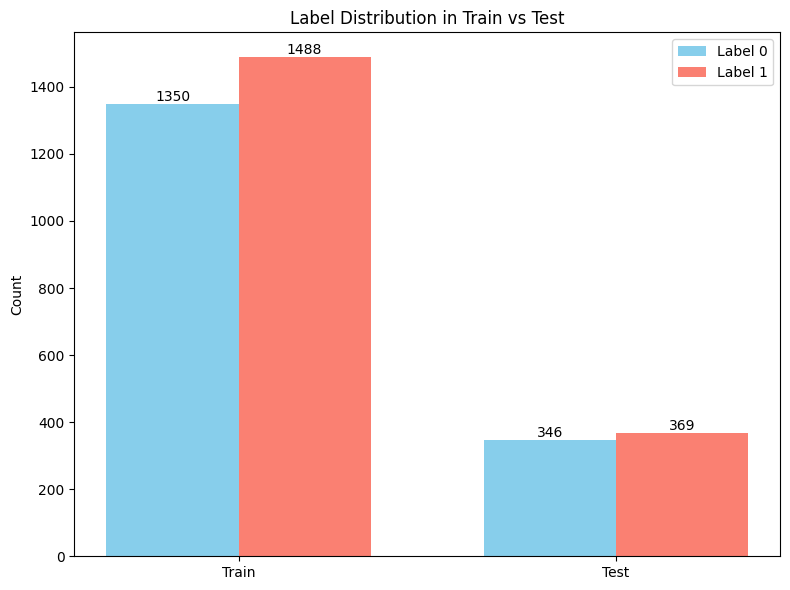

In [353]:
# Count labels
train_counts = df_train['label'].value_counts().sort_index()
test_counts = df_test['label'].value_counts().sort_index()

labels = ['Train', 'Test']
x = np.arange(len(labels))  # positions for Train and Test
width = 0.35  # width of bars

# Counts for each label
counts_label0 = [train_counts.get(0, 0), test_counts.get(0, 0)]
counts_label1 = [train_counts.get(1, 0), test_counts.get(1, 0)]

plt.figure(figsize=(8,6))
bars0 = plt.bar(x - width/2, counts_label0, width, label='Label 0', color='skyblue')
bars1 = plt.bar(x + width/2, counts_label1, width, label='Label 1', color='salmon')

plt.xticks(x, labels)
plt.ylabel('Count')
plt.title('Label Distribution in Train vs Test')
plt.legend()

# Add value labels
for bars in [bars0, bars1]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            str(height),
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.tight_layout()
plt.show()

The data is balanced. For train dataset, it is 47%-53%. For test dataset, it is 48%-52%

### Consider Class Distribution across the Subreddits

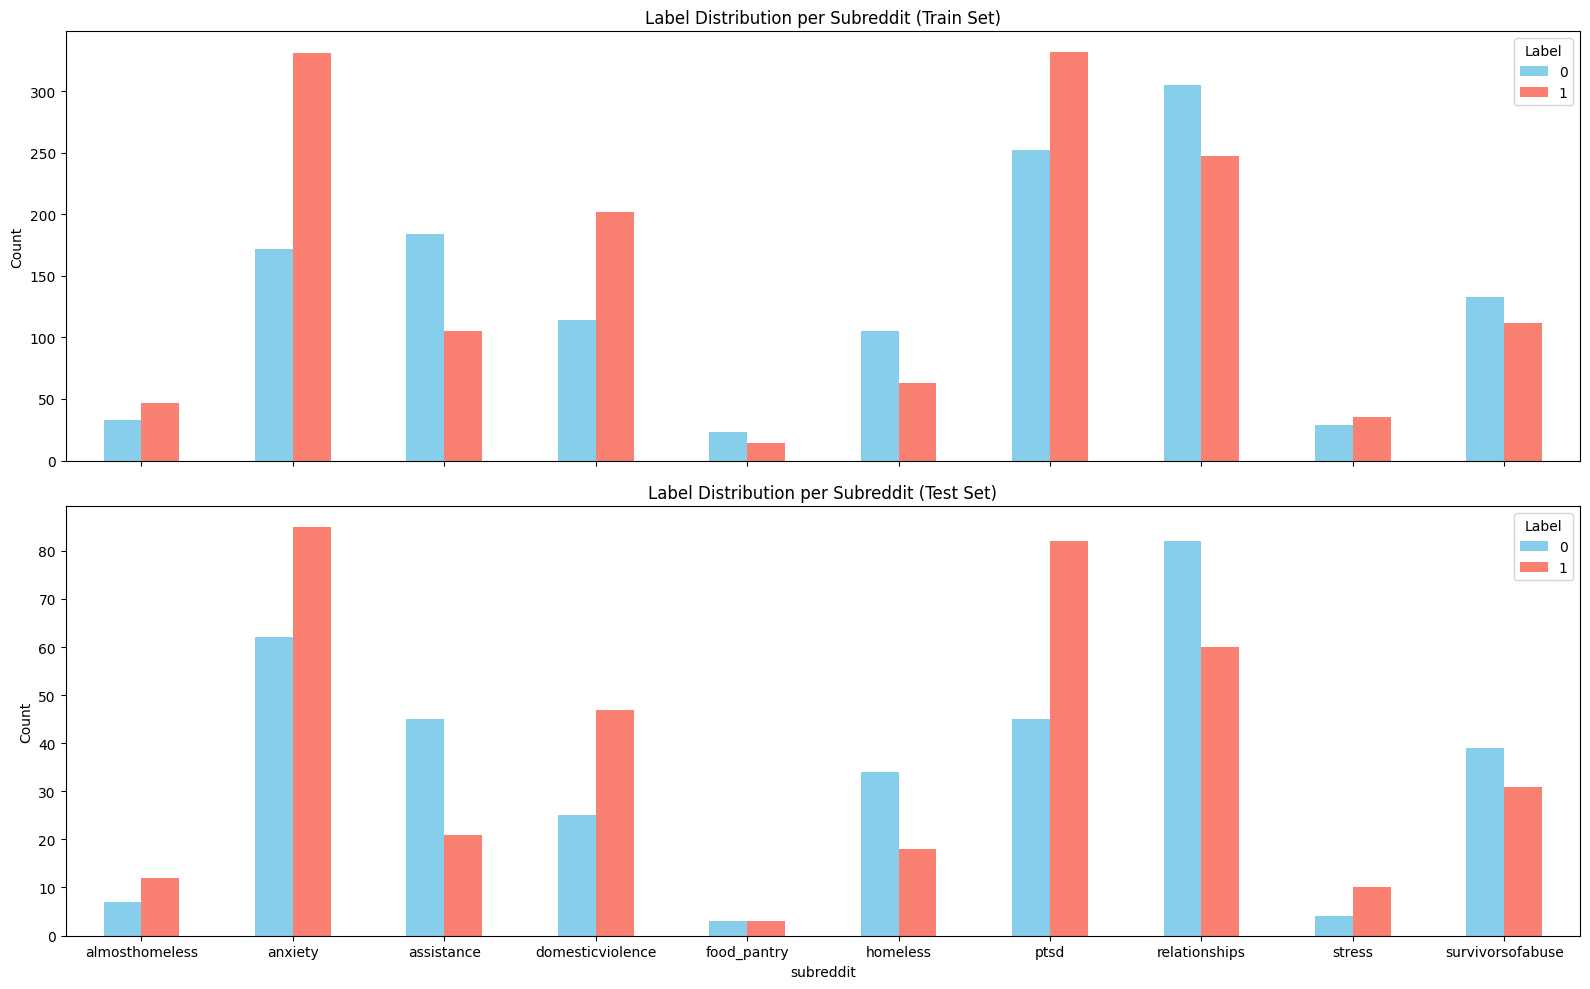

In [388]:
# Count labels per subreddit
train_counts = df_train.groupby(['subreddit', 'label']).size().unstack(fill_value=0)
test_counts  = df_test.groupby(['subreddit', 'label']).size().unstack(fill_value=0)

# Ensure same subreddit order
subreddits = sorted(set(train_counts.index).union(test_counts.index))
train_counts = train_counts.reindex(subreddits, fill_value=0)
test_counts  = test_counts.reindex(subreddits, fill_value=0)

colors = ['skyblue','salmon']

fig, axes = plt.subplots(2, 1, figsize=(16,10), sharex=True)

# --- Train Plot ---
train_counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_ylabel('Count')
axes[0].set_title('Label Distribution per Subreddit (Train Set)')
axes[0].legend(title='Label')

axes[0].set_xticks(range(len(subreddits)))
axes[0].set_xticklabels(subreddits, rotation=45, ha='right')

# --- Test Plot ---
test_counts.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_ylabel('Count')
axes[1].set_title('Label Distribution per Subreddit (Test Set)')
axes[1].legend(title='Label')

axes[1].set_xticks(range(len(subreddits)))
axes[1].set_xticklabels(subreddits, rotation=0, ha='center')

plt.tight_layout()
plt.show()

## Text Preprocessing

1. Tokenization
2. Stop Words Removal
3. Lemmatization

In [355]:
# Prepare Stop Words
stop_words = set(stopwords.words('english'))
## print(stop_words)
stop_words.remove("not")
stop_words.remove("no")
stop_words.remove("nor")
stop_words.remove("i")
stop_words.remove("me")
stop_words.remove("my")

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    doc = nlp(text.lower())
    tokens = []

    for token in doc:
        if token.is_alpha:
            if token.text not in stop_words:
                tokens.append(token.lemma_)

    tokens = [str(t) for t in tokens]
    return " ".join(tokens)

df_train_cleaned = df_train.copy()
df_test_cleaned = df_test.copy()

df_train_cleaned["cleaned_text"] = df_train_cleaned["text"].apply(preprocess_text)
df_test_cleaned["cleaned_text"] = df_test_cleaned["text"].apply(preprocess_text)

df_train_cleaned = df_train_cleaned.dropna(subset=['text', 'label'])
df_test_cleaned = df_test_cleaned.dropna(subset=['text', 'label'])

print(df_train_cleaned)

             subreddit post_id sentence_range  \
0                 ptsd  8601tu       (15, 20)   
1           assistance  8lbrx9         (0, 5)   
2                 ptsd  9ch1zh       (15, 20)   
3        relationships  7rorpp        [5, 10]   
4     survivorsofabuse  9p2gbc         [0, 5]   
...                ...     ...            ...   
2833     relationships  7oee1t       [35, 40]   
2834              ptsd  9p4ung       [20, 25]   
2835           anxiety  9nam6l        (5, 10)   
2836    almosthomeless  5y53ya        [5, 10]   
2837              ptsd  5y25cl         [0, 5]   

                                                   text     id  label  \
0     He said he had not felt that way before, sugge...  33181      1   
1     Hey there r/assistance, Not sure if this is th...   2606      0   
2     My mom then hit me with the newspaper and it s...  38816      1   
3     until i met my new boyfriend, he is amazing, h...    239      1   
4     October is Domestic Violence Awareness M

## Baseline Model: TF-IDF + Logistic Regression Classifier

### Baseline Model without Text Preprocessing

In [356]:
tfidf_bs = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_text_train_tfidf_bs = tfidf_bs.fit_transform(df_train['text'])
X_text_test_tfidf_bs = tfidf_bs.transform(df_test['text'])

clf_bs = LogisticRegression(max_iter=1000)

y_train = df_train['label']
y_test = df_test['label']
clf_bs.fit(X_text_train_tfidf_bs, y_train)

y_pred_bs = clf_bs.predict(X_text_test_tfidf_bs)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bs))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bs))

f1_bs = f1_score(y_test, y_pred_bs)  # by default, 'binary' mode
print("F1-score:", f1_bs)

Confusion Matrix:
 [[228 118]
 [ 81 288]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.66      0.70       346
           1       0.71      0.78      0.74       369

    accuracy                           0.72       715
   macro avg       0.72      0.72      0.72       715
weighted avg       0.72      0.72      0.72       715

F1-score: 0.743225806451613


### Compare Test F1-Score with K-Fold Stratified Cross Validation on Train Dataset
The purpose of doing this is to determine if the F1-Score of Test Dataset is similar, and thus reliable

In [357]:
# For Original Text
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_bs = cross_val_score(clf, X_text_train_tfidf_bs, y_train, cv=skf, scoring='f1')
print("Baseline Model Cross-Validation")
print("Cross-Validation Scores:", cv_scores_bs)
print("Average Cross-Validation Score:", cv_scores_bs.mean())

Baseline Model Cross-Validation
Cross-Validation Scores: [0.79617834 0.77419355 0.78378378 0.73927393 0.75747508 0.76582278
 0.77702703 0.78343949 0.75838926 0.78547855]
Average Cross-Validation Score: 0.7721061798451908


### Baseline Model with Text Preprocessing

In [358]:
tfidf_bs_cleaned = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_text_train_tfidf_bs_cleaned = tfidf_bs_cleaned.fit_transform(df_train_cleaned['cleaned_text'])
X_text_test_tfidf_bs_cleaned = tfidf_bs_cleaned.transform(df_test_cleaned['cleaned_text'])

clf_bs_cleaned = LogisticRegression(max_iter=1000)

y_train_cleaned = df_train_cleaned['label']
y_test_cleaned = df_test_cleaned['label']
clf_bs_cleaned.fit(X_text_train_tfidf_bs_cleaned, y_train_cleaned)

y_pred_bs_cleaned = clf_bs_cleaned.predict(X_text_test_tfidf_bs_cleaned)
print("Confusion Matrix:\n", confusion_matrix(y_test_cleaned, y_pred_bs_cleaned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bs_cleaned))

f1_bs_cleaned = f1_score(y_test_cleaned, y_pred_bs_cleaned)  # by default, 'binary' mode
print("F1-score:", f1_bs_cleaned)

Confusion Matrix:
 [[242 104]
 [ 71 298]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.70      0.73       346
           1       0.74      0.81      0.77       369

    accuracy                           0.76       715
   macro avg       0.76      0.75      0.75       715
weighted avg       0.76      0.76      0.75       715

F1-score: 0.7730220492866408


### Compare Test F1-Score with K-Fold Stratified Cross Validation on Train Dataset
The purpose of doing this is to determine if the F1-Score of Test Dataset is similar, and thus reliable

In [359]:
# For Cleaned Text
cv_scores_bs_cleaned = cross_val_score(clf, X_text_train_tfidf_bs_cleaned, y_train, cv=skf, scoring='f1')
print("Baseline Model (Preprocessed Text) Cross-Validation")
print("Cross-Validation Scores:", cv_scores_bs_cleaned)
print("Average Cross-Validation Score:", cv_scores_bs_cleaned.mean())

Baseline Model (Preprocessed Text) Cross-Validation
Cross-Validation Scores: [0.76315789 0.77602524 0.75163399 0.68013468 0.74267101 0.77358491
 0.74576271 0.76221498 0.75       0.75747508]
Average Cross-Validation Score: 0.7502660492459292


## Advanced Model: TF-IDF + Pre-Computed Features (LIWC, DAL, Sentiment) + Logistic Regression Classifier 
Predicting labels using text and computed feature values in dataset

### Exploratory Data Analysis
Determine which of the 103 Pre-Computed Features should be included in the Logistic Regression Classifier

In [360]:
# Identify LIWC, DAL and Sentiment columns
liwc_cols = [col for col in df_train.columns if col.startswith('lex_liwc')]
dal_cols = [col for col in df_train.columns if col.startswith('lex_dal')]
sentiment_cols = [col for col in df_train.columns if col.startswith('sentiment')]
numeric_cols = liwc_cols + sentiment_cols + dal_cols

df_features = df_train_cleaned[["label"] + numeric_cols].copy()

# Define x_train and x_test (text + LIWC + DAL + Sentiment features)
x_train_ad_cleaned = df_train_cleaned[['text'] + ['cleaned_text'] + ["subreddit"] + numeric_cols].copy()
x_test_ad_cleaned = df_test_cleaned[['text'] + ['cleaned_text'] + ["subreddit"] + numeric_cols].copy()

In [361]:
df_features.dtypes
df_features.corr()
#sns.heatmap(df_features.corr(), annot = True)
#plt.show

,label,lex_liwc_WC,lex_liwc_Analytic,lex_liwc_Clout,lex_liwc_Authentic,lex_liwc_Tone,lex_liwc_WPS,lex_liwc_Sixltr,lex_liwc_Dic,lex_liwc_function,...,sentiment,lex_dal_max_pleasantness,lex_dal_max_activation,lex_dal_max_imagery,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness
label,1.000000,0.100473,-0.247933,-0.403804,0.275282,-0.436005,0.065546,-0.085978,0.241536,0.236932,...,-0.305157,-0.070477,0.131128,0.037904,-0.297439,-0.032659,-0.012440,0.144963,-0.049756,-0.165470
lex_liwc_WC,0.100473,1.000000,0.021022,-0.000698,0.027033,-0.080596,0.719564,-0.035387,0.089481,0.165836,...,0.005728,0.281724,0.231100,0.246276,-0.250064,-0.294372,-0.074120,-0.061002,-0.015175,-0.064109
lex_liwc_Analytic,-0.247933,0.021022,1.000000,0.251039,-0.073139,0.168784,0.037700,0.250698,-0.468169,-0.607557,...,0.119168,0.016454,-0.043750,0.122005,0.153848,-0.026726,0.014469,0.024001,0.374442,-0.070831
lex_liwc_Clout,-0.403804,-0.000698,0.251039,1.000000,-0.665819,0.335774,0.020740,0.080387,-0.148930,-0.202792,...,0.172210,0.092993,-0.053690,0.039468,0.236082,0.015076,0.053189,-0.105091,0.250363,0.085443
lex_liwc_Authentic,0.275282,0.027033,-0.073139,-0.665819,1.000000,-0.258247,0.007359,-0.072338,0.217956,0.106216,...,-0.126075,-0.030145,0.020171,-0.006551,-0.143671,-0.051873,-0.047299,0.093748,-0.089950,-0.016854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
lex_dal_min_activation,-0.032659,-0.294372,-0.026726,0.015076,-0.051873,0.038160,-0.209766,0.043080,-0.031836,-0.082928,...,0.026460,-0.094280,-0.044130,-0.098836,0.099019,1.000000,0.106854,0.256100,0.054118,0.074514
lex_dal_min_imagery,-0.012440,-0.074120,0.014469,0.053189,-0.047299,0.007822,-0.038257,0.051479,-0.188287,-0.200408,...,-0.001107,-0.110999,-0.116099,-0.107316,0.093587,0.106854,1.000000,0.058184,0.109972,0.016777
lex_dal_avg_activation,0.144963,-0.061002,0.024001,-0.105091,0.093748,-0.126904,-0.044375,0.121473,0.063166,-0.115357,...,-0.052617,0.054254,0.302982,0.006956,-0.102689,0.256100,0.058184,1.000000,0.194025,0.108321
lex_dal_avg_imagery,-0.049756,-0.015175,0.374442,0.250363,-0.089950,-0.076727,0.009435,-0.001540,-0.208508,-0.360815,...,-0.084024,-0.042128,-0.051371,0.305449,0.030304,0.054118,0.109972,0.194025,1.000000,-0.026838


### Hyperparameter Tuning: Select the best K features to input into Logistic Regression Classifier
ANOVA test is used for feature selection. ANOVA helps to identify which features (columns) in the dataset vary significantly across categories. This helps to reduce noise in the Logistic Regression Model later.

In [362]:
selector = SelectKBest(score_func=f_classif, k = "all")

x_train_features = df_features[numeric_cols].copy()
y_train_features = df_features[["label"]].copy()

selector.fit(x_train_features, y_train_features)

scores = pd.Series(selector.scores_, index = x_train_features.columns)
scores.sort_values(ascending = False)

c:\Users\Haidah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


lex_liwc_Tone          665.667517
lex_liwc_Clout         552.525167
lex_liwc_i             541.606144
lex_liwc_negemo        502.542804
sentiment              291.207149
                          ...    
lex_dal_min_imagery      0.438938
lex_liwc_motion          0.282504
lex_liwc_filler          0.227525
lex_liwc_family          0.119832
lex_liwc_nonflu          0.068866
Length: 103, dtype: float64

In [363]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif)),
    ('clf', LogisticRegression(max_iter=1000))
])

param_grid = {
    'selector__k': list(range(1, 104)),  # 1 to 103
    'clf__C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(x_train_features, y_train_features)

best_k = grid.best_params_["selector__k"]

print("Best k:", best_k)
print("Best C:", grid.best_params_['clf__C'])
print("Best CV F1:", grid.best_score_)

Best k: 56
Best C: 0.01
Best CV F1: 0.7822215930091475


c:\Users\Haidah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Haidah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Results show that the optimal value of k is 56. Therefore, 56 pre-computed numeric features (LIWC, DAL and Sentiment) from the dataset is selected for the Logistic Regression Classifier.

### Train the Model

In [ ]:
# Choosing the top_k features
scaler_fs = StandardScaler()
X_numeric_train_ad_cleaned_scaled = scaler_fs.fit_transform(x_train_ad_cleaned[numeric_cols])

# Logistic regression on LIWC features only
clf_fs = LogisticRegression(max_iter=1000)
clf_fs.fit(X_numeric_train_ad_cleaned_scaled, y_train)

# Rank LIWC features by absolute coefficient
coef_abs = np.abs(clf_fs.coef_[0])
feature_importance = pd.DataFrame({
    'feature': numeric_cols,
    'importance': coef_abs
}).sort_values(by='importance', ascending=False)

top_k = best_k  # choose top k numeric features
top_numeric_features_cleaned = feature_importance['feature'].head(top_k).tolist()
print("Selected top Numeric features:", top_numeric_features_cleaned)

# Keep only top features
X_numeric_train_top_cleaned = x_train_ad_cleaned[top_numeric_features_cleaned]
X_numeric_test_top_cleaned = x_test_ad_cleaned[top_numeric_features_cleaned]

numeric_feature_names = X_numeric_train_top_cleaned.columns.tolist()

# -----------------------
# 2. TF-IDF on text
# -----------------------
tfidf_ad_cleaned = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_text_train_tfidf_ad_cleaned = tfidf_ad_cleaned.fit_transform(x_train_ad_cleaned['cleaned_text'])
X_text_test_tfidf_ad_cleaned = tfidf_ad_cleaned.transform(x_test_ad_cleaned['cleaned_text'])

X_text_train_df = pd.DataFrame(
    X_text_train_tfidf_ad_cleaned.toarray(),
    columns=tfidf_ad_cleaned.get_feature_names_out(),
    index=x_train_ad_cleaned.index
)
X_text_test_df = pd.DataFrame(
    X_text_test_tfidf_ad_cleaned.toarray(),
    columns=tfidf_ad_cleaned.get_feature_names_out(),
    index=x_test_ad_cleaned.index
)

tfidf_feature_names_3 = tfidf_ad_cleaned.get_feature_names_out()

#print(X_text_train_tfidf_ad_cleaned)
# -----------------------
# 3. Scale numeric  features
# -----------------------
scaler = StandardScaler()
X_numeric_train_scaled_cleaned = scaler.fit_transform(X_numeric_train_top_cleaned)
X_numeric_test_scaled_cleaned = scaler.transform(X_numeric_test_top_cleaned)

X_numeric_train_df = pd.DataFrame(
    X_numeric_train_scaled_cleaned,
    columns=X_numeric_train_top_cleaned.columns,
    index=x_train_ad_cleaned.index
)
X_numeric_test_df = pd.DataFrame(
    X_numeric_test_scaled_cleaned,
    columns=X_numeric_train_top_cleaned.columns,
    index=x_test_ad_cleaned.index
)

# -----------------------
# 4. Combine text + features
# -----------------------

X_train_combined_df = pd.concat([X_text_train_df, X_numeric_train_df], axis=1)
X_test_combined_df = pd.concat([X_text_test_df, X_numeric_test_df], axis=1)

X_numeric_train_sparse = csr_matrix(X_numeric_train_scaled_cleaned)
X_numeric_test_sparse = csr_matrix(X_numeric_test_scaled_cleaned)

X_train_combined_cleaned = hstack([X_text_train_tfidf_ad_cleaned, X_numeric_train_sparse])
X_test_combined_cleaned = hstack([X_text_test_tfidf_ad_cleaned, X_numeric_test_sparse])

combined_feature_names = list(tfidf_feature_names_3) + list(numeric_feature_names)

# -----------------------
# 5. Train Logistic Regression
# -----------------------
clf_ad = LogisticRegression(max_iter=1000)
clf_ad.fit(X_train_combined_cleaned, y_train_cleaned)

# -----------------------
# 6. Evaluate
# -----------------------
y_pred_ad_cleaned = clf_ad.predict(X_test_combined_cleaned)

print("Confusion Matrix:\n", confusion_matrix(y_test_cleaned, y_pred_ad_cleaned))
print("\nClassification Report:\n", classification_report(y_test_cleaned, y_pred_ad_cleaned))

f1 = f1_score(y_test_cleaned, y_pred_ad_cleaned)  # by default, 'binary' mode
print("F1-score:", f1)

Selected top Numeric features: ['lex_liwc_function', 'lex_liwc_affect', 'lex_liwc_negemo', 'lex_liwc_auxverb', 'lex_liwc_feel', 'lex_liwc_Clout', 'lex_liwc_article', 'lex_liwc_percept', 'lex_liwc_differ', 'lex_liwc_Tone', 'lex_liwc_posemo', 'lex_liwc_prep', 'lex_liwc_pronoun', 'lex_liwc_Apostro', 'lex_liwc_ipron', 'lex_liwc_QMark', 'sentiment', 'lex_dal_avg_pleasantness', 'lex_liwc_ingest', 'lex_liwc_risk', 'lex_liwc_focuspresent', 'lex_liwc_conj', 'lex_liwc_Dic', 'lex_liwc_WPS', 'lex_liwc_hear', 'lex_liwc_affiliation', 'lex_liwc_anx', 'lex_liwc_adverb', 'lex_liwc_death', 'lex_liwc_shehe', 'lex_liwc_focuspast', 'lex_dal_min_pleasantness', 'lex_liwc_swear', 'lex_liwc_drives', 'lex_dal_avg_imagery', 'lex_liwc_OtherP', 'lex_liwc_social', 'lex_liwc_i', 'lex_liwc_anger', 'lex_liwc_power', 'lex_liwc_informal', 'lex_liwc_bio', 'lex_liwc_space', 'lex_liwc_home', 'lex_liwc_Comma', 'lex_liwc_discrep', 'lex_liwc_negate', 'lex_liwc_cogproc', 'lex_liwc_WC', 'lex_liwc_friend', 'lex_liwc_insight', 'l

### Build Results DataFrame

In [415]:
X_test_combined_df_2 = pd.concat([x_test_ad_cleaned["text"], X_text_test_df, X_numeric_test_df], axis=1)
X_test_combined_df_2["pred_label"] = y_pred_ad_cleaned
X_test_combined_df_2["true_label"] = y_test_cleaned
X_test_combined_df_2["sub_reddit"] = x_test_ad_cleaned["subreddit"]

df_results = X_test_combined_df_2
print(df_results.columns)

# Get probabilities
y_proba = clf_ad.predict_proba(X_test_combined_cleaned)

# Add individual class probabilities
df_results["proba_0"] = y_proba[:, 0]
df_results["proba_1"] = y_proba[:, 1]

# If pred_label == 0 → use proba_0
# Else → use proba_1
df_results["pred_confidence"] = np.where(
    df_results["pred_label"] == 0,
    df_results["proba_0"],
    df_results["proba_1"]
)

Index(['text', 'abandon', 'abandonment', 'ability', 'able', 'able afford',
       'able get', 'able help', 'able leave', 'able pay',
       ...
       'lex_liwc_friend', 'lex_liwc_insight', 'lex_liwc_sad', 'lex_liwc_body',
       'lex_liwc_they', 'lex_liwc_leisure', 'lex_liwc_see', 'pred_label',
       'true_label', 'sub_reddit'],
      dtype='object', length=5060)


c:\Users\Haidah\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Model Results
| Model                                                                       | F1-Score | Recall (1)-|
|-----------------------------------------------------------------------------|----------|------------|
|TF-IDF + Logistic Regression                                                 |0.7432    |0.78        |
|TF-IDF (Preprocessed Text) + Logistic Regression                             | 0.7730   |0.81        |
|TF-IDF (Preprocessed Text) + Logistic Regression (with LIWC, DAL, Sentiment) |0.7818    | 0.82       |

### Compare Test F1-Score with K-Fold Stratified Cross Validation on Train Dataset
The purpose of doing this is to determine if the F1-Score of Test Dataset is similar, and thus reliable.

In [366]:
# For Cleaned Text
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

f1_scores = []
X_train_combined_cleaned = csr_matrix(X_train_combined_cleaned)

for train_index, val_index in skf.split(X_train_combined_cleaned, y_train):
    X_tr, X_val = X_train_combined_cleaned[train_index], X_train_combined_cleaned[val_index]
    y_tr, y_val = y_train[train_index], y_train[val_index]
    
    # Train logistic regression on this fold
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_tr, y_tr)
    
    # Predict on validation set
    y_val_pred = clf.predict(X_val)
    
    # Compute F1
    f1 = f1_score(y_val, y_val_pred)
    f1_scores.append(f1)

# -----------------------
# 3. Report results
# -----------------------
print(f"F1 scores for each fold: {f1_scores}")
print(f"Mean F1 across folds: {np.mean(f1_scores):.4f}")

F1 scores for each fold: [0.777027027027027, 0.8126984126984127, 0.819672131147541, 0.7450980392156863, 0.8, 0.8065573770491803, 0.7762237762237763, 0.7721518987341772, 0.752542372881356, 0.8143322475570033]
Mean F1 across folds: 0.7876


# Analyses

## Interpretibility 
In this section, we explore how differently Baseline (Raw Text), Baseline (Preprocessed Text) and Advanced Models makes its decisions.

### Baseline Model (Raw Text) SHAP

c:\Users\Haidah\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_linear.py:95: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


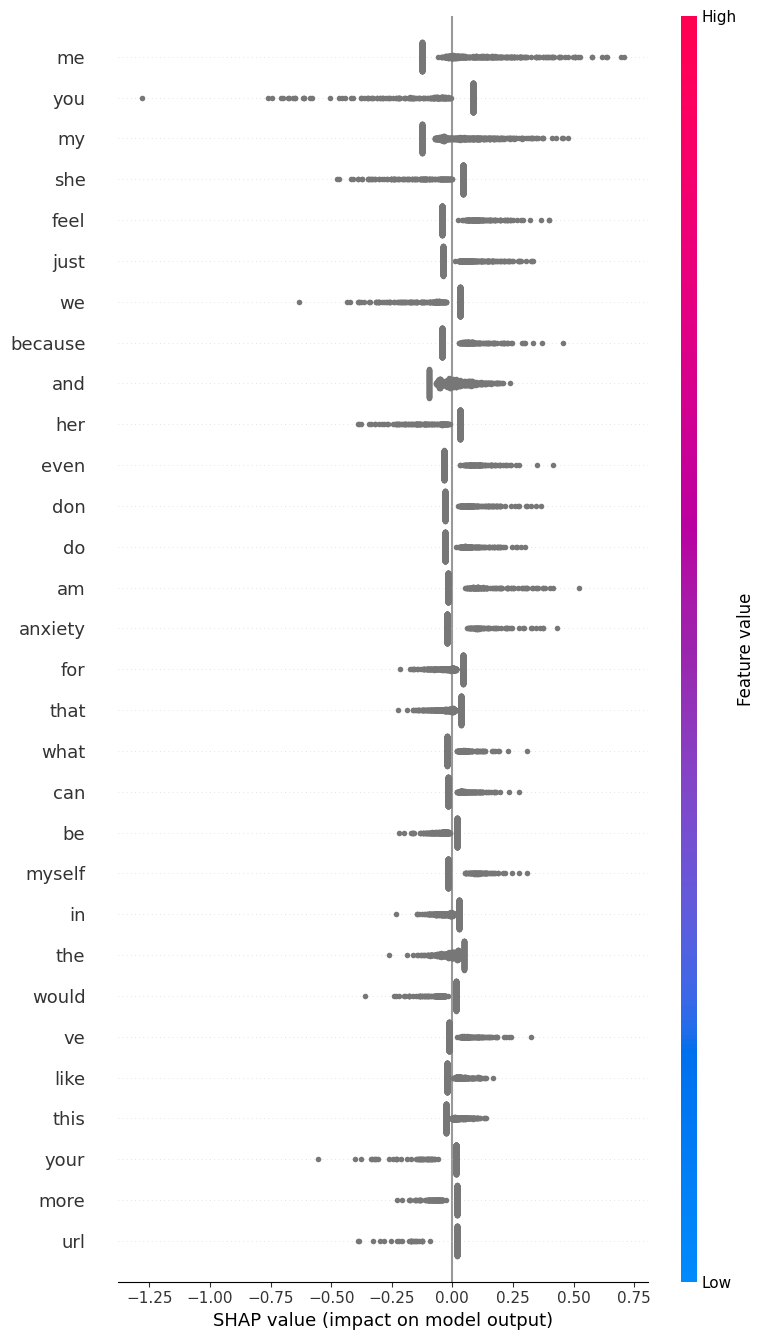

In [367]:
tfidf_feature_names_1 = tfidf_bs.get_feature_names_out()

clf_bs = LogisticRegression(max_iter=1000)
clf_bs.fit(X_text_train_tfidf_bs, y_train)

explainer_bs = shap.LinearExplainer(clf_bs, X_text_train_tfidf_bs, feature_perturbation="interventional")
shap_values_1 = explainer_bs.shap_values(X_text_test_tfidf_bs)

# SHAP summary plot
shap.summary_plot(shap_values_1, X_text_test_tfidf_bs, feature_names=tfidf_feature_names_1, max_display=30)

### Baseline Model (Cleaned Text) SHAP

c:\Users\Haidah\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_linear.py:95: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


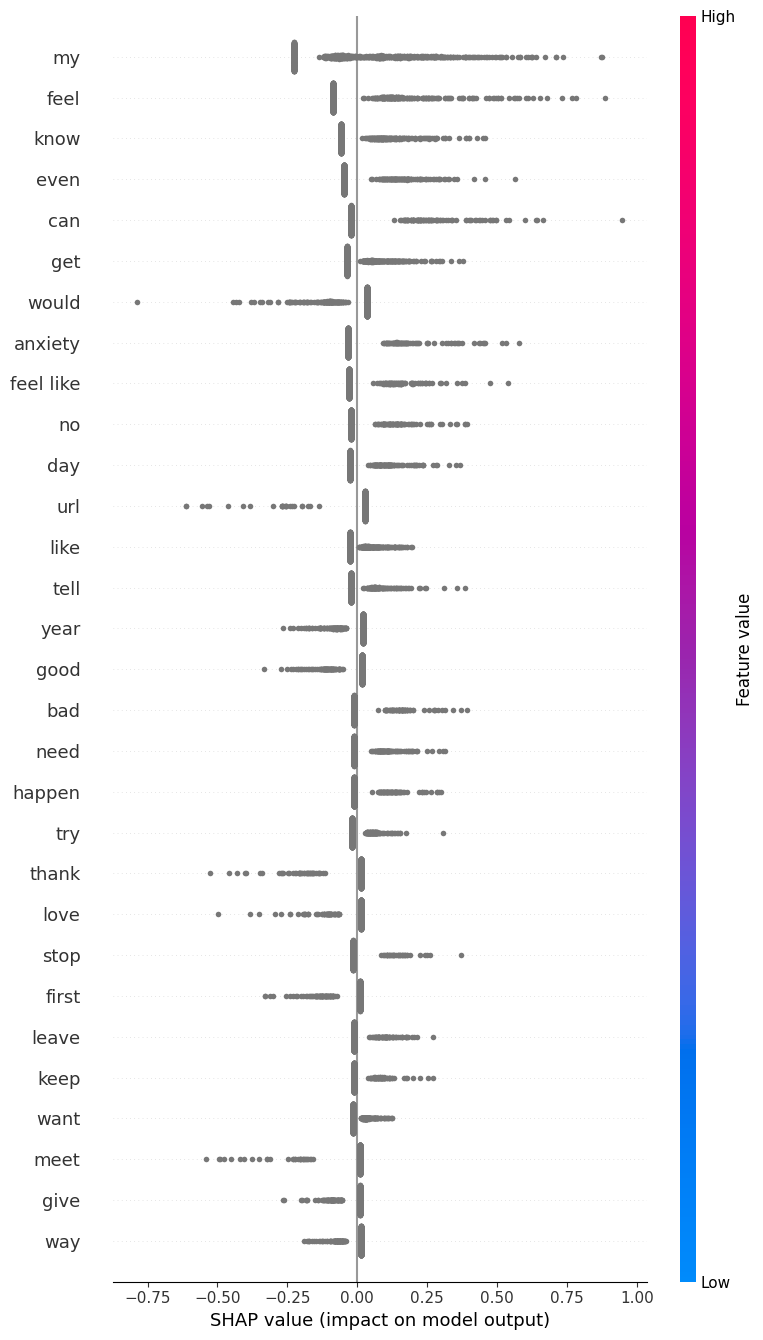

In [368]:
tfidf_feature_names_2 = tfidf_bs_cleaned.get_feature_names_out()

clf_bs_cleaned = LogisticRegression(max_iter=1000)
clf_bs_cleaned.fit(X_text_train_tfidf_bs_cleaned, y_train_cleaned)

explainer_bs_cleaned = shap.LinearExplainer(clf_bs_cleaned, X_text_train_tfidf_bs_cleaned, feature_perturbation="interventional")
shap_values_2 = explainer_bs_cleaned.shap_values(X_text_test_tfidf_bs_cleaned)

# SHAP summary plot
shap.summary_plot(shap_values_2, X_text_test_tfidf_bs_cleaned, feature_names=tfidf_feature_names_2, max_display=30)

### Advanced Model SHAP

c:\Users\Haidah\AppData\Local\Programs\Python\Python310\lib\site-packages\shap\explainers\_linear.py:95: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


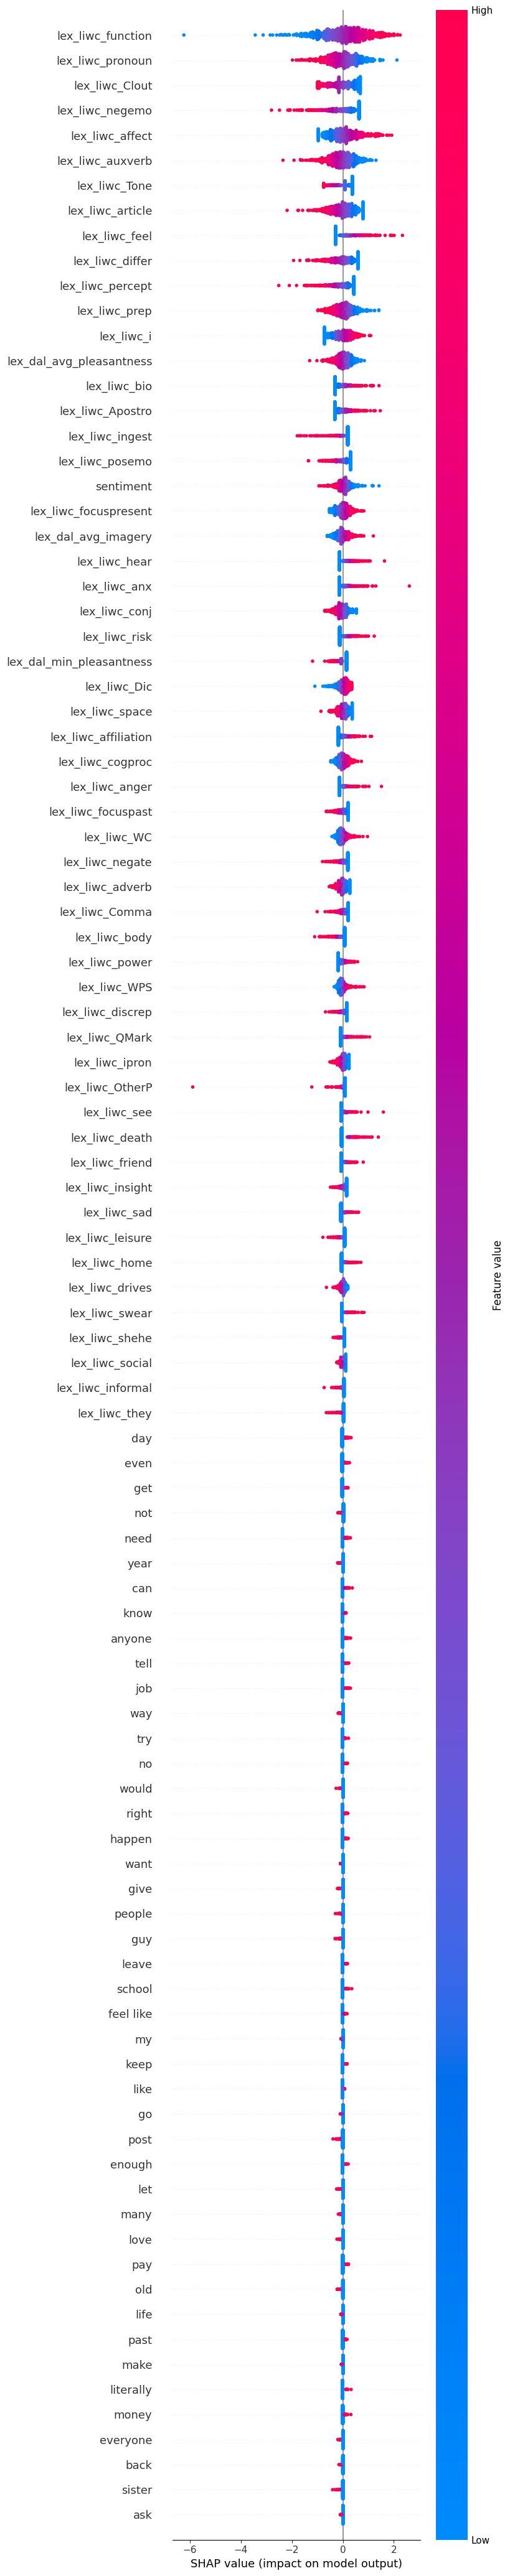

In [369]:
clf_ad = LogisticRegression(max_iter=1000)
clf_ad.fit(X_train_combined_df, y_train)

explainer_ad = shap.LinearExplainer(clf_ad, X_train_combined_df, feature_perturbation="interventional")
shap_values_ad = explainer_ad.shap_values(X_test_combined_df)

# SHAP summary plot
shap.summary_plot(shap_values_ad, X_test_combined_df, max_display=100)

From these SHAP (SHapley Additive exPlanations) values, which help break down the models' predictions by assigning each feature a "fair" contribution to the final output, we can observe how differently the Baseline Model (Raw Text), Baseline Model (Preprocessed Text) and Advanced Model make predictions.

This is a table showing the top 10 features used by each model
| No. | Baseline Model (Raw Text) | Baseline Model (Preprocessed Text) | Advanced Model |
|-----|---------------------------|------------------------------------|----------------|
|1    | me                        | my                                 | liwc_function  |
|2    | you                       | feel                               | liwc_pronoun   |
|3    | my                        | know                               | liwc_Clout     |
|4    | she                       | even                               | liwc_negemo    |
|5    | feel                      | can                                | liwc_affect    |
|6    | just                      | get                                | liwc_auxverb   |
|7    | we                        | would                              | liwc_Tone      |
|8    | because                   | anxiety                            | liwc_article   |
|9    | and                       | feel like                          | liwc_feel      |
|10   | her                       | no                                 | liwc_differ    |

For the baseline models, it can be observed that there is very little effect that each token (feature) contributes to the predictive power of the model, between -1 to 1. This implies that there is little weight given to individual tokens when it comes to predicting whether someone is stressed or not. However, when comparing the contributive power of tokens between Raw Text and Preprocessed Text, the nature of the top contributing tokens differ. For example, the top 10 tokens in the Baseline Model (Raw Text) consists of relatively uninformative words such as "just" and "because". For the Baseline Model (Preprocessed Text) top 10, words such as "anxiety" and "no" exists. This implies that the preprocessing step of removing Stop Words is effective as more informative words contribute to the predictive power of the model. For example, the word "anxiety" ranks 15th for the Baseline Model (Raw Text), but ranks 8th for the Baseline Model (Preprocessed Text).

It can also be observed that the top token identified as most important in the Baseline Predictive Models is "me" and "my". This is an interesting observation and supports research which have found that the frequent use of I-talk (the use of personal pronouns) is linked to proneness of stress. (Tackman et al., 2019) Furthermore, it is interesting that the top words associated with classification of stressed and not stressed is not complicated and extreme words, but rather simplistic ones such as "feel" and "even".

When LIWC, DAL and Sentiment Scores are included in the Predictive Model, it can be observed that these pre-computed features are more important than the weight of individual tokens. This is expected given that LIWC, Linguistic Inquiry and Word Count carries the emotional linguistic insights from the text. The top LIWC associated with the predictive model for stress centres personal talk, use of pronouns, languages of leadership, negative emotions and affection.

## Segment by Subreddit and consider Model Performance

In [405]:
# List to collect results per subreddit
summary_list = []

# Iterate over each subreddit
for sub in df_results['sub_reddit'].unique():
    df_sub = df_results[df_results['sub_reddit'] == sub]
    y_true = df_sub['true_label']
    y_pred = df_sub['pred_label']
    
    # Compute metrics
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    recall_1 = recall_score(y_true, y_pred, pos_label=1)
    precision_0 = precision_score(y_true, y_pred, pos_label=0)
    
    summary_list.append({
        'sub_reddit': sub,
        'macro_f1': macro_f1,
        'recall_1': recall_1,
        'precision_0': precision_0
    })

# Create summary_df
summary_df = pd.DataFrame(summary_list)


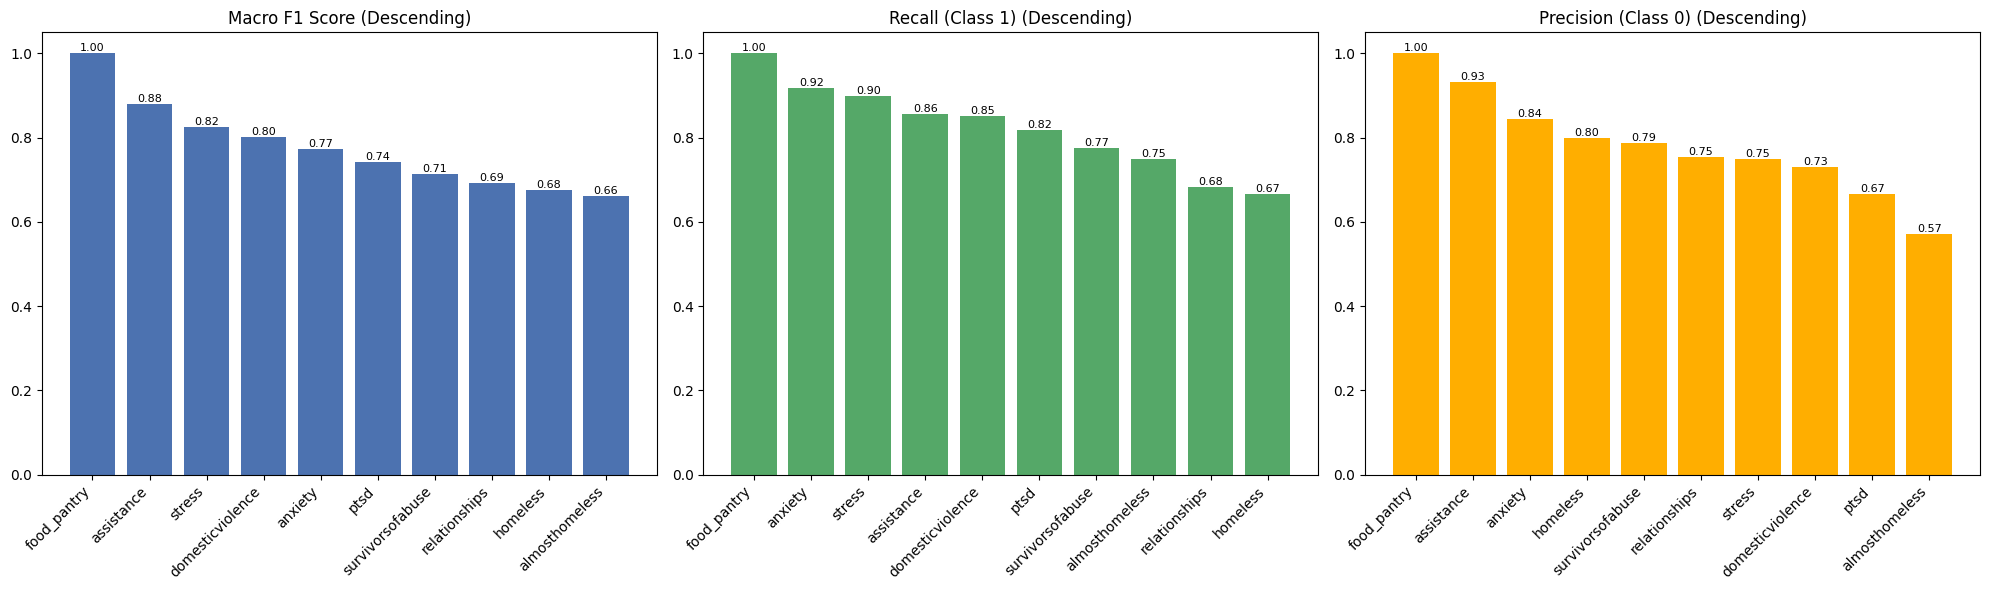

In [406]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Consistent colors
color_f1 = "#4C72B0"
color_recall = "#55A868"
color_precision = "#FFAE00"

# --------------------------------------------------
# 1️⃣ Macro F1 (sorted by macro_f1)
df_f1 = summary_df.sort_values("macro_f1", ascending=False)
x1 = np.arange(len(df_f1))

bars1 = axes[0].bar(x1, df_f1["macro_f1"], color=color_f1)
axes[0].set_title("Macro F1 Score (Descending)")
axes[0].set_xticks(x1)
axes[0].set_xticklabels(df_f1["sub_reddit"], rotation=45, ha="right")
axes[0].set_ylim(0, 1.05)

# --------------------------------------------------
# 2️⃣ Recall (Class 1) sorted by recall_1
df_recall = summary_df.sort_values("recall_1", ascending=False)
x2 = np.arange(len(df_recall))

bars2 = axes[1].bar(x2, df_recall["recall_1"], color=color_recall)
axes[1].set_title("Recall (Class 1) (Descending)")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(df_recall["sub_reddit"], rotation=45, ha="right")
axes[1].set_ylim(0, 1.05)

# --------------------------------------------------
# 3️⃣ Precision (Class 0) sorted by precision_0
df_precision = summary_df.sort_values("precision_0", ascending=False)
x3 = np.arange(len(df_precision))

bars3 = axes[2].bar(x3, df_precision["precision_0"], color=color_precision)
axes[2].set_title("Precision (Class 0) (Descending)")
axes[2].set_xticks(x3)
axes[2].set_xticklabels(df_precision["sub_reddit"], rotation=45, ha="right")
axes[2].set_ylim(0, 1.05)

# --------------------------------------------------
# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        bar.axes.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.show()

When segmented by Subreddit, it is found that the generally, when comparing F1-Score, the model performs the best for Subreddit "food_pantry" and the worst for Subreddit "almosthomeless". Recall for label=1 is extremely crucial as it there is higher stakes for the model to be able to correctly identify a case as stressed out of all actual stressed cases. Precision for label=0 is also important as it is crucial to be able to be correctly predict an actual non-stressed cases as non-stressed. From these results, we can see that the model is able to predict the presence and absence of stress more correctly in some subreddits than others.

The likely reason why the F1-Score, Recall and Precision for subreddit "food_pantry" is 1.0 is that the test sample size is very small, of 6 data points only. However, it is interesting that all 6 data points are categorised correctly.

### Analyse Text under subreddit "food_pantry"

In [412]:
# Filter for the specific subreddit
df_food = df_results[df_results['sub_reddit'] == "food_pantry"]

# Sample 3 rows where true_label = 0
sample_0 = df_food[df_food['true_label'] == 0]

# Sample 3 rows where true_label = 1
sample_1 = df_food[df_food['true_label'] == 1]

# Combine the samples
sample_combined = pd.concat([sample_0, sample_1]).reset_index(drop=True)

# Select only the desired columns
sample_display = sample_combined[['text', 'sub_reddit', 'true_label', 'pred_label', 'pred_confidence']]

# Set pandas options to display full text
pd.set_option('display.max_colwidth', None)  # Show full text
pd.set_option('display.max_rows', None)      # Show all rows

# Display the DataFrame
sample_display

,text,text,sub_reddit,true_label,pred_label,pred_confidence
0,"Hi all. I recently moved to another country and it pretty much cost everything to get set up here. My roommate just moved out to start a new chapter with their significant other, taking pretty much all the furniture with them and naturally, rent has gone up. I'm wiped out until the 17th. I, my wife and daughter would appreciate any help to tide us over.",0.0,food_pantry,0,0,0.820694
1,"You all saved me. Really. I got plenty of easy to make breakfast stuff so I can make myself a nice hot meal quickly and easily on my crutches, and I’ve got some high protein snacks like nuts, sardines, and turkey jerky to keep me going during the day when I don’t have anyone to help me cook the rice or quinoa I got sent. I’ve got green beans to make green bean casserole, tea and coffee to keep me sane and comfortable while I’m in so much pain. Some people were even kind enough to purchase an Uber giftcard to help me get to doctor’s appointments since I can’t use the public transit until I’m in a walking boot or have a wheelchair (wheelchair should be in a couple of days!)",0.0,food_pantry,0,0,0.522470
2,"But whatever. I got paid today, so food is no longer an emergency and I wouldn't feel right accepting your gifts of compassion. Thank you all so much thoughfor your efforts. I'm in no way in a good position financially at the moment, but at least for the time being I'm not in pain. Thanks again and god bless.",0.0,food_pantry,0,0,0.822736
3,"I was laid off work temporarily and the insurance I was getting stopped over a week ago suddenly. I can't get back to work until next Monday earliest. I sold some stuff online locally a few days ago, got more stuff listed but it's not moving and almost all of what I made online went to fee's when I renewed my license plates. I have literally nothing but a few days more of plain rice left. I figured I may as well give this sub a shot.",0.0,food_pantry,1,1,0.579049
4,"Due to recent medical issues of mine (I was hospitalized for anorexia), we had to pay 1,000 dollars for my hospital bills. We paid our bills due to help from a relative, but now we have nothing left. My mom is sick and can't work, my brother is mentally disabled, as is my sister. I feel defeated, I don't want to beg, but I have no options left. Any help would be appreciated (We have been to our food bank, but four people consume a lot of food.",0.0,food_pantry,1,1,0.828801
5,I’m just getting done with my training at my new job which I’m so thankful to have. It’s just that I’m down to my last $40 in my bank account and I don’t get paid for another 2 weeks. I’ve been eating peanut butter and jelly to get by but it’s becoming really hard and also depressing. I’ve never been this anxious about how I’m going to eat but here I am. Please help me.,0.0,food_pantry,1,1,0.909795


From this, it can be observed that subreddit "food_pantry" is not a regular or common subreddit people interact with, but rather one that people are likely to turn to in likely only 2 cases, when in need of food (label=0) or to thank other users for food provided and offered (label=1). This is likely the reason why the predictive model is able to correctly predict "stressed" or "not stressed" for all the cases in the test set. As food can be categorised as a physiological basic need under Maslow's Heirarchy of Needs, and given that users tend to turn to this subreddit in desperate times, the presence and absence of food sends a strong signal for the presence or absence of stress. There is low ambiguity about stress in these texts.

If this is the case for food_pantry, then it is curious that performance for "homeless" and "almosthomeless" is the lowest. Shelter is also identified as a physiological basic need under Maslow's Heirarchy of Needs. In the next part, we explore the nature of texts under the subreddits "homeless" and "almosthomeless".

### Analyse texts under subreddits "homeless" and "almosthomeless"

#### Analysing texts under subreddit "homeless"
Since subreddit "homeless" records the lowest recall score of 0.67, let's compare specific cases where the predictive model categorises a true_label=1 with pred_label=0 against cases where it is rightfully pred_label=1.

In [413]:
# Filter for the specific subreddit
df_homeless = df_results[df_results['sub_reddit'] == "homeless"]

# Sample 3 rows where true_label = 0
sample_2 = df_homeless[(df_homeless['true_label'] == 1 ) & (df_homeless["pred_label"] == 0)].sample(n=3, random_state=42)

# Sample 3 rows where true_label = 1
sample_3 = df_homeless[(df_homeless['true_label'] == 1) & (df_homeless["pred_label"] == 1)].sample(n=3, random_state=42)

# Combine the samples
sample_combined_2 = pd.concat([sample_2, sample_3]).reset_index(drop=True)

# Select only the desired columns
sample_display_2 = sample_combined_2[['text', 'sub_reddit', 'true_label', 'pred_label', 'pred_confidence']]

# Set pandas options to display full text
pd.set_option('display.max_colwidth', None)  # Show full text
pd.set_option('display.max_rows', None)      # Show all rows

# Display the DataFrame
sample_display_2

,text,text,sub_reddit,true_label,pred_label,pred_confidence
0,"Hello all, for the next two years I’ll probably be living in my truck. I am going to college for free (thanks AmeriCorps) but I can’t afford to live in a real home. So I live in my truck. Any tips for keeping it clean and keeping things orderly? It’s so much harder than I thought it would be.",0.0,homeless,1,0,0.686017
1,"Do you huddle up in the corner of some obscure building that's out of the way? Under a pine tree that's thick enough to prevent any outsiders knowing you're there? Those are kind of the best ideas I have... but I really don't know and I would greatly appreciate any advice. I don't want to give too many details but I live in a city of just over 100,000 people. I'm already on food and medical assistance.",0.0,homeless,1,0,0.627612
2,"Their plan is so bad that some days I want to go out and be homeless on my own, with my own plan but I feel that it would be a bad decision to be on the streets. We've stayed at a couple of relatives places but my mom always messes it up (she's r/raisedbynarcissists material) so we left the first time (her brother) but the second time (her sister) we got kicked out. This was mostly a rant but I'd like some advice - any advice would be nice. Tell me I'm not crazy for wanting to leave California. Should I even try to convince them?",0.0,homeless,1,0,0.719916
3,"My boyfriend and I are out of options, night has fallen and we have no place to stay for the night. We're terrified beyond all reason. Neither of us has been this bad off before, and all nearby shelters have closed their doors for the night. All we have are two suitcases with our clothes and our phones. Where do we sleep in the city?",0.0,homeless,1,1,0.753377
4,"I am in a very bad situation, stuck in Nashville, with no friends or family and no money. I have some personal belongings that I am trying to sell, but can't see myself raising more than $100. Food stamps don't come in for another two weeks. I am 19. The plan is to hop on a Greyhound to Atlanta, and stay at Covenant House.",0.0,homeless,1,1,0.678862
5,I don’t get paid again until 9/1/18. This is the only low cost apartment near my school. What can I do? I’m desperately in need help and it has to be paid. Very comfortable and willing to show proof of security deposit from the leasing portal.,0.0,homeless,1,1,0.868908


Comparing true stressed texts with pred_label=0 against pred_label=1, it can be observed that the tone of texts with pred_label=0 tends to be calmer and words used are less extreme. It can also be observed that for texts with pred_label=0, users seem to express coping with homelessness, while for pre_label=1, texts tend to express their dire state. This suggests that the predictive model is not as able to identify the presence of stress in cases where users are coping.

#### Analysing texts under subreddit "almosthomeless"
Since subreddit "almosthomeless" records the lowest precision score of 0.57, let's compare specific cases where the predictive model categorises a true_label=0 with pred_label=1 against cases where it is rightfully pred_label=0.

In [414]:
# Filter for the specific subreddit
df_almhomeless = df_results[df_results['sub_reddit'] == "almosthomeless"]

# Sample 3 rows where true_label = 0
sample_4 = df_almhomeless[(df_almhomeless['true_label'] == 0 ) & (df_almhomeless["pred_label"] == 1)].sample(n=3, random_state=42)

# Sample 3 rows where true_label = 1
sample_5 = df_almhomeless[(df_almhomeless['true_label'] == 0) & (df_almhomeless["pred_label"] == 0)].sample(n=3, random_state=42)

# Combine the samples
sample_combined_3 = pd.concat([sample_4, sample_5]).reset_index(drop=True)

# Select only the desired columns
sample_display_3 = sample_combined_3[['text', 'sub_reddit', 'true_label', 'pred_label', 'pred_confidence']]

# Set pandas options to display full text
pd.set_option('display.max_colwidth', None)  # Show full text
pd.set_option('display.max_rows', None)      # Show all rows

# Display the DataFrame
sample_display_3

,text,text,sub_reddit,true_label,pred_label,pred_confidence
0,"Backstory: My late grandparents home, the home I was raised and still currently live in, is being short sold to a relative by the bank. My grandparent did a reverse mortgage, died and their home went into foreclosure, got put up for a short sale, and is now in the closing process. The relative who's purchasing the home clearly wants to profit off of the home and is warning me that in the coming days it'll be time for me to go. Unfortunately, my next stop will be a shelter as I have no money saved up to move into an apartment of my own, nor do I make enough working part-time to pay rent, and I don't have many ready available options that I'm aware of. The only question I have is does the relative have to pay us to move out or can they just kick us to the curb without a penny?",0.0,almosthomeless,0,1,0.830735
1,"And I think it's important to get to know someone for a bit before making a decision to live together. I'm happy to send pictures of me, talk via voice, webcam, or whatever. The major restriction I have is that it will have to be at specific times because my abusive partner is home most days. I also will have to speak with anyone on secret messaging accounts when the abusive partner is not home, so I am not always available to talk about this but I check those accounts as much as possible. Due to anticipated trolling and people just asking questions that I've already answered (like telling me to go to a shelter instead), rather than coming back to all these posts (I'm posting this on a ton of websites) to see the replies, I'm just going to let anyone who is serious about speaking to me message me privately through the following places.",0.0,almosthomeless,0,1,0.615466
2,") So anyway, she kicked me out and I have been staying in my friend's rumpus room. I have been here just over a week now and I can feel it getting slightly more uncomfortable for everyone here the longer I stay. Problem is though: this is actually the nicest ""room"" I have ever been in, and no one disturbs me. It's great.",0.0,almosthomeless,0,1,0.881420
3,"and money will be tight. I sometimes augment my income with Mturk, but additional advice on how to make a little extra cash would be appreciated (would have to be one time gigs though due to the nature of my disability, I can't hold down a long term job. Stuff like plasma donation, opinion surveys, medical studies, etc.) Any kind of life hacks, government assistance, etc. that I do not know about would be appreciated.",0.0,almosthomeless,0,0,0.867700
4,"I am the caseworker of about 300+ homeless men in my city. This number fluctuates, and I help them with anything and everything. If our shelter doesn't offer it, I usually know where to send them or find out for them. I am here to offer a few basic tips just to help anyone out. You are more than welcome to message me about any questions you have.",0.0,almosthomeless,0,0,0.816612
5,I don't have anyone to borrow money from. I need help coming up with ways to create additional income asap. Love to all you out there going through a similar struggle. We got this! !,0.0,almosthomeless,0,0,0.776972


Similarly, for true not stressed texts, when comparing pred_label=1 and pred_label=0, it can be observed that the not stressed texts wrongly predicted as stress tend to convey a certain level of coping with the stress. In the first text, a negative scenario of becoming homeless is supplemented by a question whether the situation is lawful, while in the second text, the negative scenario of having an abusive partner is followed by the nonchalant private message requests. In the third text, the user is kicked out, but finds positivity in the situation. This supports the previous hypothesis that the predictive model struggles to classify texts as stressed or not stressed when the text expresses coping strategies.

Compared to subreddit "food_pantry", the nature of texts in subreddits "homeless" and "almosthomeless" tend to be more ambiguous with users seeking advise or coping strategies with their situation. It is likely because of the limitation of the predictive model for ambiguous texts that the performance for subreddits "almosthomeless" and "homeless" is the lowest as compared to subreddit "food_pantry". This is contrary to the initial narrative that the model should predict well for subreddits "food_pantry", "homelessness", "almosthomeless", which are Physiological Basic Needs in Maslow's Hierarchy of Needs.


# Conclusion
In conclusion, this predictive model may not be perfectly accurate in identifying the presence or absence of stress in individuals. However, it's relatively high recall score for Stressed Texts (0.82) suggests that the model is quite reliable in identifying stress in actually stressed individuals. It is most important to be able to identify Stress in actual Stressed Texts for this case.

In a real-world setting, this predictive model can be used in annonymous chatbots or helplines to flag out texts from individuals who may be at risk of stress. Such identification of stress is useful as an early warning system for individuals to take action before high levels of stress cause insignificant, long-term harm to mental health. 

However, given that the model struggles with identification of stress for texts with ambiguous, contemplative and coping tones, this model is more suited for identification of stress at a preliminary stage. The text inputted into the chatbot or helpline likely needs to convey a certain dire state and desperation for accurate classification. For texts with ambiguous, contemplative and coping tones, it would be useful for the chatbot or helpline to be supplemented with a system which is able to capture this and flag it to experts who would be able to provide a proper diagnosis upon further investigation. It must be noted that for the model to be highly robust, the texts should undergo pre-computing of LIWC, DAL and Sentiment Scores as well.